In [5]:
import pandas as pd

df = pd.read_excel("./../csv/library_id_cond.xlsx")

In [6]:
df['library_id'] = df['library_id'].str.replace("_","-")

In [7]:
df = df[df['cond']!= "UNC"]

In [8]:
df

,library_id,cond
0,18-57617-A1,IPF
1,20-33940-B2,IPF
2,20-24241-A2,IPF
3,19-35057-C3,NSIP
4,20-17688-B2,NSIP
5,20-28197-A1,IPF
6,20-22642-A1,NSIP
7,20-41501-C1,IPF
8,20-33362-C4,NSIP
10,20-41615-B1,IPF


In [9]:
df['IPF_onehot']  = (df['cond']=='IPF').astype(int)

In [10]:
df

,library_id,cond,IPF_onehot
0,18-57617-A1,IPF,1
1,20-33940-B2,IPF,1
2,20-24241-A2,IPF,1
3,19-35057-C3,NSIP,0
4,20-17688-B2,NSIP,0
5,20-28197-A1,IPF,1
6,20-22642-A1,NSIP,0
7,20-41501-C1,IPF,1
8,20-33362-C4,NSIP,0
10,20-41615-B1,IPF,1


In [11]:
df = df.reset_index(drop = True)

In [12]:
df.shape

(29, 3)

In [13]:
from sklearn.model_selection import StratifiedKFold  # or KFold if labels are not categorical

k = 4  # number of folds
y = df["IPF_onehot"]  # or your label column

skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(df, y)):
    colname = f"fold_{fold_idx}"
    
    df.loc[train_idx,colname] = "train"
    
    df.loc[test_idx, colname] = "test"


In [14]:
df

,library_id,cond,IPF_onehot,fold_0,fold_1,fold_2,fold_3
0,18-57617-A1,IPF,1,train,train,train,test
1,20-33940-B2,IPF,1,test,train,train,train
2,20-24241-A2,IPF,1,train,test,train,train
3,19-35057-C3,NSIP,0,train,test,train,train
4,20-17688-B2,NSIP,0,train,train,train,test
5,20-28197-A1,IPF,1,test,train,train,train
6,20-22642-A1,NSIP,0,test,train,train,train
7,20-41501-C1,IPF,1,train,train,test,train
8,20-33362-C4,NSIP,0,train,test,train,train
9,20-41615-B1,IPF,1,test,train,train,train


In [15]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import h5py
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score

from trident.slide_encoder_models import ABMILSlideEncoder

# Set deterministic behavior
SEED = 1234
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


class BinaryClassificationModel(nn.Module):
    def __init__(self, input_feature_dim=1536, n_heads=1, head_dim=512, dropout=0., gated=True, hidden_dim=256):
        super().__init__()
        self.feature_encoder = ABMILSlideEncoder(
            freeze=False,
            input_feature_dim=input_feature_dim, 
            n_heads=n_heads, 
            head_dim=head_dim, 
            dropout=dropout, 
            gated=gated
        )
        self.classifier = nn.Sequential(
            nn.Linear(input_feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x, return_raw_attention=False):
        if return_raw_attention:
            features, attn = self.feature_encoder(x, return_raw_attention=True)
        else:
            features = self.feature_encoder(x)
        logits = self.classifier(features).squeeze(1)
        
        if return_raw_attention:
            return logits, attn
        
        return logits

# Initialize model
device = 'mps'
model = BinaryClassificationModel().to(device)

# Custom dataset
class H5Dataset(Dataset):
    def __init__(self, feats_path, df, split, test_idx = None, num_features=1536):
        #self.df = df[df["fold_0"] == split]
        #self.df = df.drop(test_idx)
        self.df = df[df[f"fold_{test_idx}"] == split]
        self.feats_path = feats_path
        self.num_features = num_features
        self.split = split
    
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with h5py.File(os.path.join(self.feats_path, row['library_id'] + '.h5'), "r") as f:
            features = torch.from_numpy(f["features"][:])

        if self.split == 'train':
            num_available = features.shape[0]
            if num_available >= self.num_features:
                indices = torch.randperm(num_available, generator=torch.Generator().manual_seed(SEED))[:self.num_features]
            else:
                indices = torch.randint(num_available, (self.num_features,), generator=torch.Generator().manual_seed(SEED))  # Oversampling
            features = features[indices]

        label = torch.tensor(row["IPF_onehot"], dtype=torch.float32)
        return features, label

# # Create dataloaders
# feats_path = '/Users/jk/Documents/Lab2/visium/python_analysis/trident/svs/trident_processed/20x_256px_0px_overlap/features_uni_v2'  #'./tutorial-3/cptac_ccrcc/20x_512px_0px_overlap/features_conch_v15'
# batch_size = 22
# train_loader = DataLoader(H5Dataset(feats_path, df, "train"), batch_size=batch_size, shuffle=False, worker_init_fn=lambda _: np.random.seed(SEED))
# test_loader = DataLoader(H5Dataset(feats_path, df, "test"), batch_size=1, shuffle=False, worker_init_fn=lambda _: np.random.seed(SEED))





In [32]:
# Stuff that doesnt change 
feats_path = '/Users/jk/Documents/Lab2/visium/python_analysis/cpath/trident/svs/trident_processed/20x_256px_0px_overlap/features_uni_v2'  #'./tutorial-3/cptac_ccrcc/20x_512px_0px_overlap/features_conch_v15'
batch_size = 21
# Training setup
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=4e-4)

all_labels = [] # to be a list of array where each index contains labels from one CV fold
all_outputs = []
# Put ABMIL inside LOOCV loop
for i in range(k):
    print(f"K fold {i+1}/{k})")

    # Split
    train_dataset = H5Dataset(feats_path, df, "train", test_idx=i)
    test_dataset = H5Dataset(feats_path, df, "test", test_idx=i)  # single sample
    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, worker_init_fn=lambda _: np.random.seed(SEED))
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

    # Initialize fresh model per fold
    model = BinaryClassificationModel().to(device)
    optimizer = optim.Adam(model.parameters(), lr=4e-4)
    criterion = nn.BCEWithLogitsLoss()

    # Train model
    num_epochs = 20
    for epoch in range(num_epochs):
        model.train()
        for features, labels in train_loader:
            features, labels = {'features': features.to(device)}, labels.to(device)
            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Evaluate on held-out sample
    model.eval()
    with torch.no_grad():
        for features, labels in test_loader:
            features, labels = {'features': features.to(device)}, labels.to(device)
            outputs = model(features)
            all_outputs.append(outputs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())


K fold 1/4)
K fold 2/4)
K fold 3/4)
K fold 4/4)


In [ ]:
from sklearn.metrics import roc_auc_score, confusion_matrix
import numpy as np

all_labels = np.concatenate(all_labels)
all_outputs = np.concatenate(all_outputs)

# AUC
auc = roc_auc_score(all_labels, all_outputs)

# Binary predictions
preds = (all_outputs > 0).astype(int)  # logit > 0

# Accuracy
accuracy = (preds == all_labels).mean()d

# Confusion matrix
cm = confusion_matrix(all_labels, preds)

print(f"LOOCV Accuracy: {accuracy:.4f}")
print(f"LOOCV AUC: {auc:.4f}")
print("Confusion Matrix:")
print(cm)

LOOCV Accuracy: 0.6207
LOOCV AUC: 0.6368
Confusion Matrix:
[[13  6]
 [ 5  5]]


In [34]:
all_labels

array([1., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 1., 0.,
       0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0.], dtype=float32)

In [35]:
all_outputs

array([  1.4762944 ,   1.4123291 ,   5.001145  ,   4.904579  ,
         5.6332445 , -10.118435  ,  -5.113571  ,  -5.6667805 ,
        -0.6136543 ,  -2.7692306 ,  -1.4526546 ,  -2.2745636 ,
        -4.3638325 ,  -3.0066206 ,  -1.9255512 ,   0.8606398 ,
        -1.6781274 ,  -2.672571  ,  -3.0068746 ,  -2.8320348 ,
        -0.85687715,  -2.7182615 ,  -1.6184063 ,   4.3298926 ,
         2.0587888 ,  -6.207146  ,   1.5984939 ,   1.2322377 ,
         2.3379352 ], dtype=float32)

In [38]:
np.savez("epoch_20_k_4_results", all_labels = all_labels, all_outputs = all_outputs)

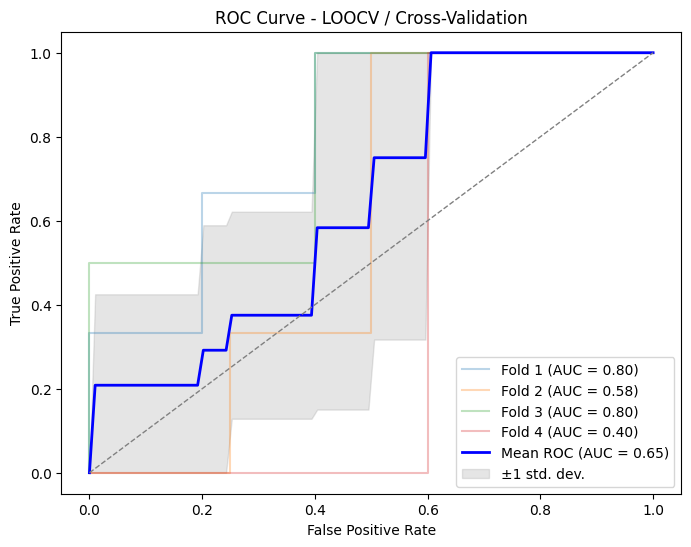

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

plt.figure(figsize=(8,6))

mean_fpr = np.linspace(0, 1, 100)  # common x-axis
tprs = []  # store interpolated TPRs
k = len([c for c in df.columns if c.startswith("fold_")])  # number of folds

for i in range(k):
    # Get mask for test samples in fold i
    test_mask = df[f"fold_{i}"] == "test"
    
    # Extract labels and outputs for this fold
    labels_fold = all_labels[test_mask.values]
    outputs_fold = all_outputs[test_mask.values]
    
    fpr, tpr, _ = roc_curve(labels_fold, outputs_fold)
    roc_auc = auc(fpr, tpr)
    
    # Interpolate TPR at standard FPR points
    tpr_interp = np.interp(mean_fpr, fpr, tpr)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)
    
    plt.plot(fpr, tpr, alpha=0.3, label=f'Fold {i+1} (AUC = {roc_auc:.2f})')

# Compute mean TPR and AUC
tprs = np.array(tprs)
mean_tpr = tprs.mean(axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)

# Compute std TPR 
std_tpr = tprs.std(axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

# Plot mean ROC and shaded std area
plt.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=0.2, label='±1 std. dev.')

# Random chance line
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LOOCV / Cross-Validation')
plt.legend(loc='lower right')
plt.show()
